# 🛒 Amazon India Sales Analysis (Mar–Jun 2022)
**Objective:** Understand sales patterns, top-performing categories, regional trends, and cancellation behavior across 121K+ orders.

**Dataset:** Amazon Sale Report — real e-commerce data from Amazon India  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly  

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
df = pd.read_csv("Amazon Sale Report.csv" , low_memory=False)

print("Shape:" , df.shape)
df.head()

Shape: (128975, 24)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("Shape:" , df.shape)
print()
print("columns:" , list(df.columns))

Shape: (128975, 24)

columns: ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [5]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [6]:
#Check Missing Values
df.isna().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

## Data Cleaning
**Steps:**
- Drop useless columns (index, promotion-ids, currency, ASIN, SKU, Unnamed)
- Convert Date to datetime and extract Month
- Drop rows with missing Amount or ship-state
- Normalize state names to Title Case
- Create `is_cancelled` flag

In [7]:
# Deop Useless Columns
df.drop(columns=['index','promotion-ids', 'fulfilled-by', 'Unnamed: 22',
                 'currency','ASIN', 'SKU'], inplace=True)

#Convert Date To Datetime and Extract Month

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

#Drop rows with missing Amount or ship-state
df.dropna(subset=['Amount', 'ship-state'], inplace=True)

#Normalize state names to Title Case
df['ship-state'] = df['ship-state'].str.title()

#Cancelation Flag
df['is_Cancelled'] = df['Status'].str.lower().str.contains('cancel').astype(int)

print("Shape after cleaning:", df.shape)
print("Nulls remaining:")
print(df.isna().sum())

Shape after cleaning: (121149, 20)
Nulls remaining:
Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
Category                 0
Size                     0
Courier Status        5133
Qty                      0
Amount                   0
ship-city                0
ship-state               0
ship-postal-code         0
ship-country             0
B2B                      0
Month                    0
Month_Name               0
is_Cancelled             0
dtype: int64


In [8]:
df['Courier Status'].unique()

array([nan, 'Shipped', 'Unshipped'], dtype=object)

In [9]:
# الـ nulls في الـ cancelled نملاها بـ "Not Shipped"
df['Courier Status'] = df.apply(
    lambda row: 'Not Shipped' 
    if pd.isna(row['Courier Status']) and 'cancel' in row['Status'].lower() 
    else row['Courier Status'], 
    axis=1
)

# الـ nulls الباقية (8 delivered + 3 returned) نملاها من الـ Status
df['Courier Status'].fillna('Shipped', inplace=True)

# تحقق
print(df['Courier Status'].value_counts())
print("Nulls remaining:", df['Courier Status'].isna().sum())

Courier Status
Shipped        109461
Unshipped        6555
Not Shipped      5133
Name: count, dtype: int64
Nulls remaining: 0


In [10]:
df.isna().sum()

Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
Category              0
Size                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
Month                 0
Month_Name            0
is_Cancelled          0
dtype: int64

## 5. Data Analysis & Visualization

### 5.1 Revenue by Category

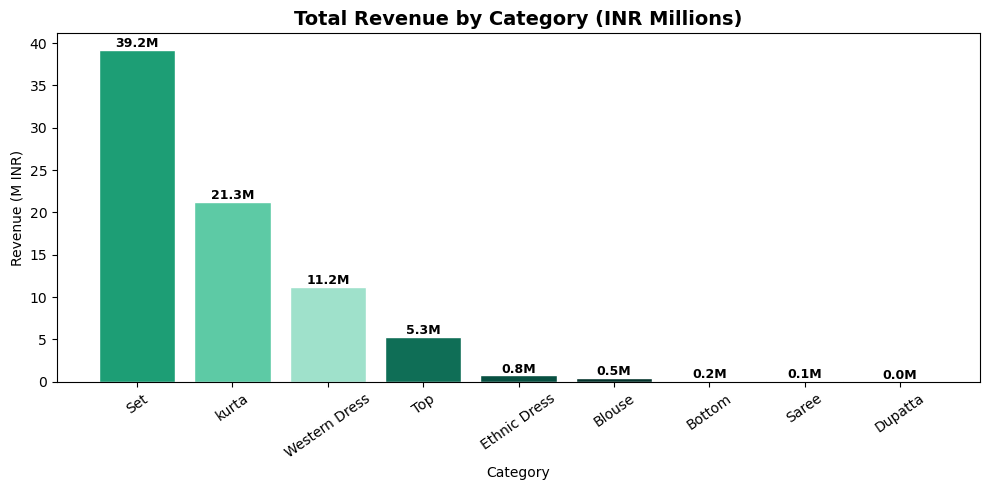

In [11]:
Cat_Sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(Cat_Sales.index, Cat_Sales.values / 1e6,
        color=['#1D9E75','#5DCAA5','#9FE1CB','#0F6E56','#085041','#04342C','#E1F5EE','#04342C','#1D9E75'],
        edgecolor='white')
plt.title("Total Revenue by Category (INR Millions)" , fontsize=14 , fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Revenue (M INR)')
plt.xticks(rotation=35)
for i ,v in enumerate (Cat_Sales.values):
    plt.text(i,v/1e6+0.3,f'{v/1e6:.1f}M' , ha='center' , fontsize=9 , fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Monthly Revenue Trend

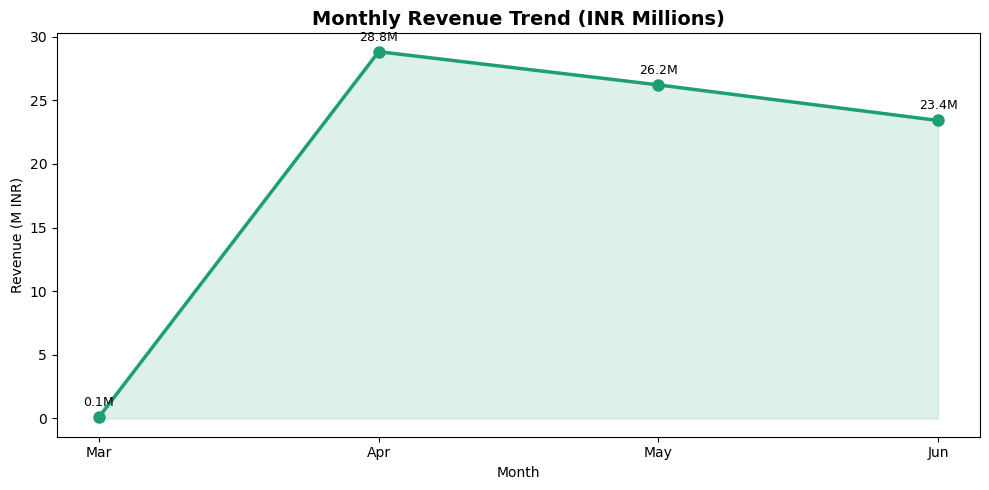

In [12]:
Monthely = df.groupby(['Month' , 'Month_Name'])['Amount'].sum().reset_index().sort_values('Month')

plt.figure(figsize=(10,5))

plt.plot(Monthely['Month_Name'], Monthely['Amount']/1e6,
         marker='o', color='#1D9E75', linewidth=2.5, markersize=8)

plt.fill_between(Monthely['Month_Name'], Monthely['Amount']/1e6,
                 alpha=0.15, color='#1D9E75')

plt.title('Monthly Revenue Trend (INR Millions)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (M INR)')

for i, v in enumerate(Monthely['Amount']/1e6):
    plt.annotate(f"{v:.1f}M", (i, v),
                 textcoords='offset points', xytext=(0,8),
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
print(type(plt.xlabel))

<class 'function'>


### 5.3 Top 10 States by Revenue

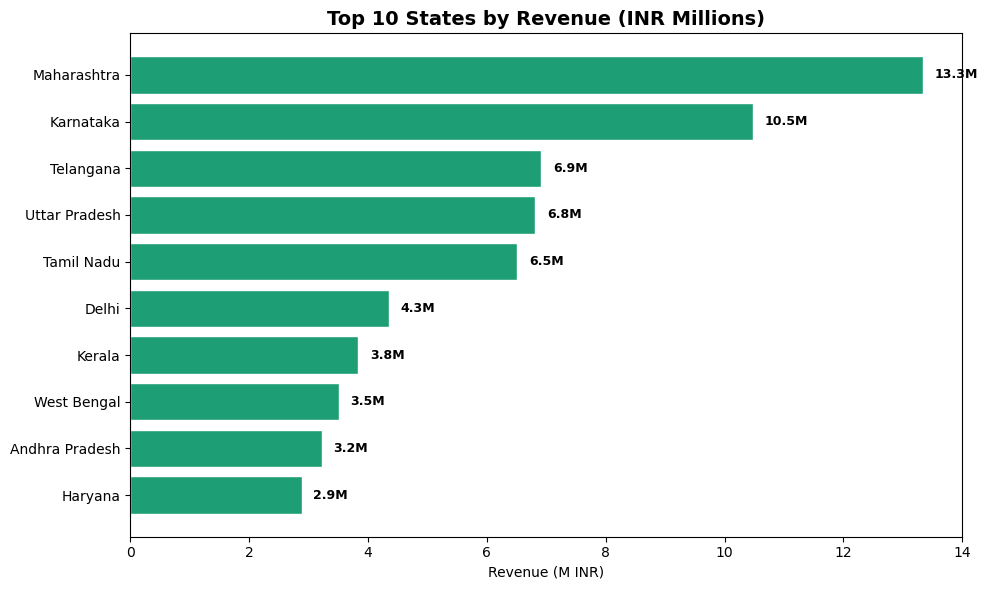

In [16]:
Top_States = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(Top_States.index[::-1] , Top_States.values[::-1]/1e6 , color='#1D9E75', edgecolor='white')
plt.title('Top 10 States by Revenue (INR Millions)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (M INR)')
for i, v in enumerate(Top_States.values[::-1]):
    plt.text(v/1e6 + 0.2, i, f'{v/1e6:.1f}M',
             va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Cancellation Rate by Category

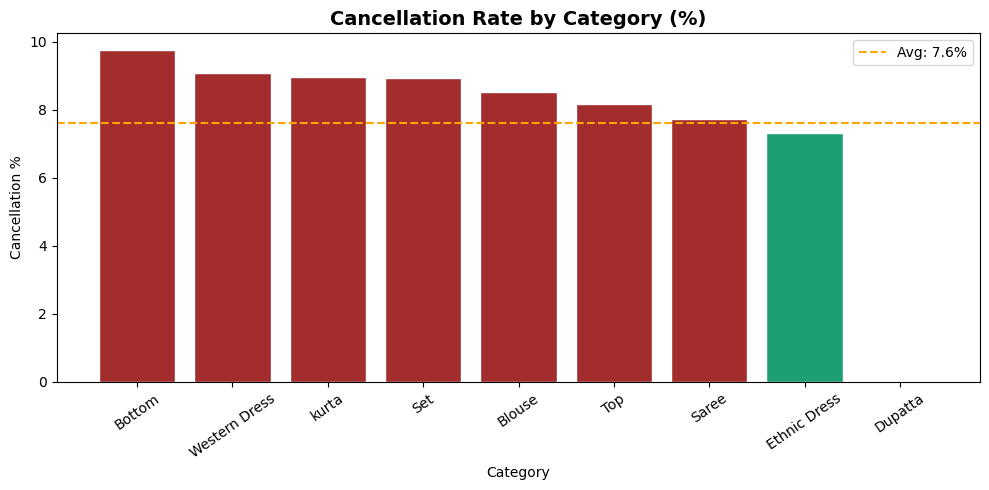

In [20]:
cancel_rate = df.groupby('Category')['is_Cancelled'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
plt.bar(cancel_rate.index, cancel_rate.values,
        color=['#A32D2D' if v > cancel_rate.mean() else '#1D9E75' for v in cancel_rate.values],
        edgecolor='white')
plt.axhline(y=cancel_rate.mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Avg: {cancel_rate.mean():.1f}%')
plt.title('Cancellation Rate by Category (%)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Cancellation %')
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()

### 5.5 Category Distribution (Interactive)

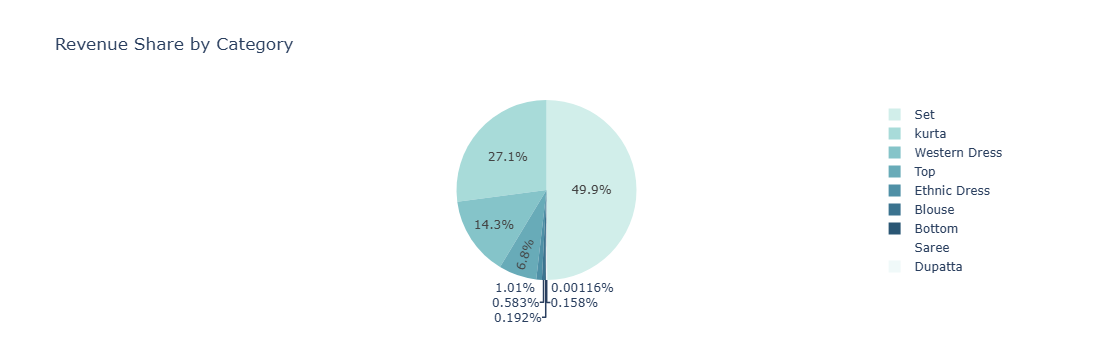

In [21]:
fig = px.pie(df, names='Category', values='Amount',
             title='Revenue Share by Category',
             color_discrete_sequence=px.colors.sequential.Teal)
fig.show()

## 6. Key Insights

| # | Insight |
|---|---------|
| 1 | **Set** is the top category with **INR 39.2M** — nearly 50% of total revenue |
| 2 | **April** was the best month with **INR 28.8M** in revenue |
| 3 | **Maharashtra** leads all states with **INR 13.3M** |
| 4 | Overall cancellation rate is **8.9%** — within acceptable range |
| 5 | Some categories have higher cancellation — worth investigating pricing or descriptions |

## 7. Recommendations

- **Double down on Sets & Kurtas** — they drive the most revenue
- **Investigate April spike** — was it a sale event? Replicate it
- **Focus marketing on Maharashtra, Karnataka, Delhi** — top 3 states
- **Reduce cancellations** in high-cancel categories by improving product descriptions